In [2]:
import subprocess
subprocess.run(['/cvmfs/soft.ccr.buffalo.edu/versions/2023.01/easybuild/software/avx512/Compiler/gcccore/11.2.0/python/3.9.6/bin/python', '-m', 'pip', 'install', '--user', 'numpy'], capture_output=True, text=True)

CompletedProcess(args=['/cvmfs/soft.ccr.buffalo.edu/versions/2023.01/easybuild/software/avx512/Compiler/gcccore/11.2.0/python/3.9.6/bin/python', '-m', 'pip', 'install', '--user', 'numpy'], returncode=0, stdout='Requirement already satisfied: numpy in /user/qkhatib/.local/lib/python3.9/site-packages (2.0.2)\n', stderr="WARNING: You are using pip version 21.2.2; however, version 26.0.1 is available.\nYou should consider upgrading via the '/cvmfs/soft.ccr.buffalo.edu/versions/2023.01/easybuild/software/avx512/Compiler/gcccore/11.2.0/python/3.9.6/bin/python -m pip install --upgrade pip' command.\n")

In [3]:
import sys
sys.path.insert(0, '/user/qkhatib/.local/lib/python3.9/site-packages')
import importlib
if 'typing_extensions' in sys.modules:
    del sys.modules['typing_extensions']
import numpy as np
print('numpy:', np.__version__)

numpy: 2.0.2


In [4]:
import pickle
import matplotlib.pyplot as plt

with open('../data/processed/training_data_def2svp.pkl', 'rb') as f:
    data = pickle.load(f)

print(f'Loaded {len(data)} molecules')
print(f'Molecules: {sorted(data.keys())}')

Loaded 16 molecules
Molecules: ['S1000_b3lyp', 'S1010_b3lyp', 'S1020_b3lyp', 'S1030_b3lyp', 'S1040_b3lyp', 'S1050_b3lyp', 'S1060_b3lyp', 'S1080_b3lyp', 'S1090_b3lyp', 'S1100_b3lyp', 'S1130_b3lyp', 'S1140_b3lyp', 'S1150_b3lyp', 'S1160_b3lyp', 'S1170_b3lyp', 'S1180_b3lyp']


In [5]:
def extract_features(mol_data):
    """Extract fixed-size features from variable-size molecular data."""
    ci = mol_data['ci_vector']
    hdiag = mol_data['hdiag']
    ci_hdiag = mol_data['ci_hdiag']
    
    features = [
        mol_data['grad_norm'],       # 1. orbital gradient norm
        mol_data['energy'],          # 2. total energy
        np.max(np.abs(ci)),          # 3. dominant CI coefficient
        np.min(np.abs(ci)),          # 4. smallest CI coefficient
        np.mean(np.abs(ci)),         # 5. mean CI coefficient
        np.std(ci),                  # 6. spread of CI coefficients
        np.max(hdiag),               # 7. max orbital curvature
        np.min(hdiag),               # 8. min orbital curvature
        np.mean(hdiag),              # 9. mean orbital curvature
        np.std(hdiag),               # 10. spread of orbital curvature
        np.mean(ci_hdiag),           # 11. mean CI curvature
        np.std(ci_hdiag),            # 12. spread of CI curvature
    ]
    return np.array(features)

# Build X and y
names = sorted(data.keys())
X = np.array([extract_features(data[n]) for n in names])
y = np.array([data[n]['ci_hdiag'] for n in names])

print(f'Feature matrix X shape: {X.shape}')
print(f'Target matrix y shape: {y.shape}')
print(f'Feature names: grad_norm, energy, max_ci, min_ci, mean_ci, std_ci, max_hdiag, min_hdiag, mean_hdiag, std_hdiag, mean_ci_hdiag, std_ci_hdiag')

Feature matrix X shape: (16, 12)
Target matrix y shape: (16, 400)
Feature names: grad_norm, energy, max_ci, min_ci, mean_ci, std_ci, max_hdiag, min_hdiag, mean_hdiag, std_hdiag, mean_ci_hdiag, std_ci_hdiag


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Train/test split - hold out 2 molecules for testing
X_train, X_test, y_train, y_test, names_train, names_test = train_test_split(
    X, y, np.array(names), test_size=2, random_state=42
)

print(f'Training set: {len(X_train)} molecules')
print(f'Test set: {len(X_test)} molecules')
print(f'Test molecules: {names_test}')

# Normalize features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

print('\nFeatures normalized!')

# Save
np.save('../data/processed/X_train.npy', X_train_scaled)
np.save('../data/processed/X_test.npy', X_test_scaled)
np.save('../data/processed/y_train.npy', y_train_scaled)
np.save('../data/processed/y_test.npy', y_test_scaled)
np.save('../data/processed/names_test.npy', names_test)
print('Saved train/test splits!')

Training set: 14 molecules
Test set: 2 molecules
Test molecules: ['S1000_b3lyp' 'S1010_b3lyp']

Features normalized!
Saved train/test splits!


In [7]:
import torch
import torch.nn as nn

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test_scaled)

# Define the neural network
class HessianPredictor(nn.Module):
    def __init__(self, input_size=12, hidden_size=64, output_size=400):
        super(HessianPredictor, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )
    
    def forward(self, x):
        return self.network(x)

model = HessianPredictor()
print('Model architecture:')
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters())}')

Model architecture:
HessianPredictor(
  (network): Sequential(
    (0): Linear(in_features=12, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=400, bias=True)
  )
)

Total parameters: 30992


In [8]:
# Training
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

losses = []
print('Training...')
for epoch in range(2000):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train_tensor)
    loss = loss_fn(y_pred, y_train_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 400 == 0:
        print(f'  Epoch {epoch:4d} | Loss: {loss.item():.6f}')

print('Training complete!')

Training...
  Epoch    0 | Loss: 1.014516
  Epoch  400 | Loss: 0.001224
  Epoch  800 | Loss: 0.000144
  Epoch 1200 | Loss: 0.000029
  Epoch 1600 | Loss: 0.000004
Training complete!


In [9]:
# Evaluate on test set
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test_tensor).numpy()

# Convert back to original scale
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_actual = y_test

# Calculate error for each test molecule
print('=== Test Results ===')
for i, name in enumerate(names_test):
    mae = np.mean(np.abs(y_pred[i] - y_actual[i]))
    rel_error = mae / np.mean(np.abs(y_actual[i])) * 100
    print(f'{name}: MAE={mae:.4f}, Relative Error={rel_error:.2f}%')

# Overall error
mae_total = np.mean(np.abs(y_pred - y_actual))
rel_error_total = mae_total / np.mean(np.abs(y_actual)) * 100
print(f'\nOverall relative error: {rel_error_total:.2f}%')

=== Test Results ===
S1000_b3lyp: MAE=0.1163, Relative Error=2.34%
S1010_b3lyp: MAE=0.1736, Relative Error=3.69%

Overall relative error: 3.00%


In [10]:
# Print predicted vs actual CI Hessian diagonal
for i, name in enumerate(names_test):
    print(f'\n=== {name} ===')
    print(f'{"Index":<8} {"Actual":<15} {"Predicted":<15} {"Error":<10}')
    print('-' * 50)
    for j in range(len(y_actual[i])):
        actual_val = y_actual[i][j]
        pred_val = y_pred[i][j]
        error = abs(pred_val - actual_val)
        print(f'{j:<8} {actual_val:<15.6f} {pred_val:<15.6f} {error:<10.6f}')


=== S1000_b3lyp ===
Index    Actual          Predicted       Error     
--------------------------------------------------
0        -6.025727       -6.135715       0.109988  
1        -5.665502       -5.788563       0.123061  
2        -5.692010       -5.886525       0.194515  
3        -5.510161       -5.779674       0.269513  
4        -5.734576       -5.634921       0.099655  
5        -5.675138       -5.877642       0.202504  
6        -5.643532       -5.716962       0.073430  
7        -5.398447       -5.519816       0.121369  
8        -5.292403       -5.463451       0.171048  
9        -5.318760       -5.422127       0.103367  
10       -5.735652       -5.675268       0.060384  
11       -5.668582       -5.782031       0.113449  
12       -5.627753       -5.596277       0.031477  
13       -5.398752       -5.516373       0.117622  
14       -5.283484       -5.382489       0.099005  
15       -5.302209       -5.453011       0.150801  
16       -5.355559       -5.402618       0.0

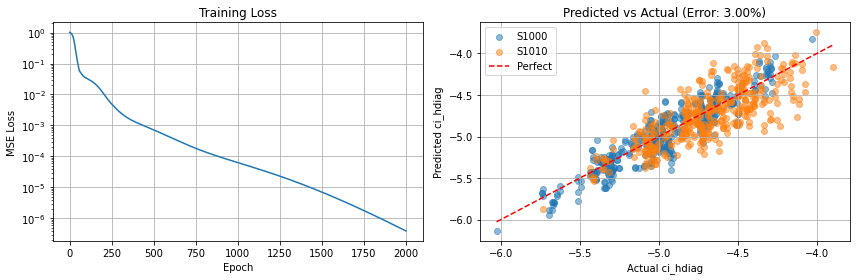

Plot saved!


In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1 - Training loss
axes[0].plot(losses)
axes[0].set_yscale('log')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True)

# Plot 2 - Predicted vs Actual
for i, name in enumerate(names_test):
    axes[1].scatter(y_actual[i], y_pred[i], alpha=0.5, label=name.replace('_b3lyp',''))

axes[1].plot([y_actual.min(), y_actual.max()], 
             [y_actual.min(), y_actual.max()], 'r--', label='Perfect')
axes[1].set_xlabel('Actual ci_hdiag')
axes[1].set_ylabel('Predicted ci_hdiag')
axes[1].set_title(f'Predicted vs Actual (Error: {rel_error_total:.2f}%)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../results/plots/02_model_results.png', dpi=150)
plt.show()
print('Plot saved!')

In [12]:
import os

# Create results directory
os.makedirs('../results/models', exist_ok=True)
os.makedirs('../results/plots', exist_ok=True)

# Save model
torch.save(model.state_dict(), '../results/models/pytorch_hessian_predictor.pt')
print('Model saved!')

# Save scalers
import pickle
with open('../results/models/scaler_X.pkl', 'wb') as f:
    pickle.dump(scaler_X, f)
with open('../results/models/scaler_y.pkl', 'wb') as f:
    pickle.dump(scaler_y, f)
print('Scalers saved!')

Model saved!
Scalers saved!
